# What makes a UK road crash turn serious — and does the burden fall unequally?
## 是什么让英国车祸变严重 —— 这份负担是否落得不公平?

I'm a student handed ~308k real UK road collisions (2021–22) and one practical question a **regional road‑safety / public‑health team** faces: with a limited budget to prevent **KSI** outcomes (the official DfT *Killed‑or‑Seriously‑Injured* measure), **where and on what should they act?** / 我面对 ~30.8 万起英国真实车祸(2021–22)和一个**区域道路安全/公卫团队**的现实问题:预算有限,要减少 **KSI(死亡或重伤)**,**该在哪里、针对什么下手?**

**Why this is costly / 为什么这有代价:** failing to flag a crash‑context that turns out severe (a false negative) means a preventable death or life‑changing injury — far costlier than an unnecessary safety check (a false positive). I already suspect plain accuracy will be the wrong yardstick. / 漏掉一个会变致命的情境(FN)= 一条本可避免的人命,远贵于一次多余的安全排查(FP);我已怀疑"准确率"不是对的尺子。

**My three opening questions (answers unknown to me now) / 我开篇的三个问题(此刻我并不知道答案):**
1. Can pre‑crash road context even predict how severe a crash becomes? / 撞之前的路况,究竟能不能预测车祸有多严重?
2. Which conditions drive severity? / 哪些条件在抬高严重度?
3. Does severity fall unequally across rich vs poor areas — and if so, which way? / 严重度在贫富地区间是否不均 —— 若不均,朝哪个方向?

**My plan / 我的攻法:** understand → predict honestly → interrogate *who bears it* → turn into action. I'll JOIN an external source (England **IMD** deprivation) to ask Q3. I deliberately state **no conclusions here** — they live at the end (§14). / 先懂→诚实预测→追问"谁承受"→变成行动;外接英格兰 **IMD** 贫困指数回答 Q3;**这里不下结论**,结论在 §14。

> *Method note / 方法说明:* every tool below carries a short **"Why (statistical reasoning)"** justification before it runs, and a **"📊 Read‑out"** interpretation after. / 下方每个工具运行前有"**为什么(统计理由)**",运行后有"**📊 结果解读**"。

## Data & sources / 数据与来源
- **Primary (Kaggle):** `xavierberge/road-accident-dataset` — real DfT STATS19 GB collisions, 307,973 rows × 23 cols, 2021–22. / 主集:真实 DfT STATS19,30.8万×23,2021–22。
- **External JOIN:** English **Indices of Multiple Deprivation 2019 (IMD)**, LAD level (gov.uk, File_10). A *different viewpoint* (socio‑economic) keyed on Local Authority District. / 外部:英格兰 **IMD 2019**(LAD 级),按地方政府区连接。
- *Download:* https://www.kaggle.com/datasets/xavierberge/road-accident-dataset ; https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019

## 1. Environment & reproducibility / 环境与可复现
**Why / 为什么:** a fixed seed + explicit paths make every number in this notebook reproducible from a single Run‑All — a grading and scientific requirement (results must not depend on run order or chance). / 固定种子+显式路径,确保一键复现——评分与科学性都要求结果不依赖运行顺序或偶然。

In [1]:
import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
RANDOM_STATE=42; np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns",60); sns.set_theme(style="whitegrid")
BASE=Path(r"/Users/xilaiwang/Library/Mobile Documents/com~apple~CloudDocs/Warwick/Data Analytics & Artificial Intelligence"); assert BASE.exists()


## 2. Load the data / 加载数据
**Why read the index as text / 为什么把索引列读成文本:** validation found `Accident_Index` was corrupted by Excel into scientific notation (`2.01E+12`) for ~36% of rows. Reading it as a string stops further coercion; crucially I will **never key dedup / grouping / clustered SE on it** (it would treat 110k distinct crashes as one). / 验证发现 `Accident_Index` 被 Excel 损坏成科学计数法(约36%行),读成字符串防再损坏,且**绝不拿它做去重/分组/聚类SE**。

In [2]:
acc=pd.read_csv(BASE/"Road Accident dataset"/"Road Accident Data.csv",
                encoding="utf-8-sig", dtype={"Accident_Index":str}, low_memory=False)
print("shape:", acc.shape)
print("\ndtypes:\n", acc.dtypes.to_string())
acc.head(3)

shape: (307973, 23)

dtypes:
 Accident_Index                 object
Accident Date                  object
Month                          object
Day_of_Week                    object
Year                            int64
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Carriageway_Hazards            object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object


,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,-0.201349,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,-0.199248,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,-0.179599,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car


## 3. Before trusting anything — is this data real? / 信任之前:数据是真的吗?
**Why / 为什么:** many Kaggle sets are synthetic and inflate model AUC to ~0.95+. Two cheap statistical tells of *real* data: (a) **univariate AUC** of each feature against the target should be modest (no single feature trivially separates); (b) money/continuous fields should be smooth long‑tailed, geography within valid bounds. A synthetic teaching set engineered to "work" leaves artificial separation. / 很多 Kaggle 集是合成的、AUC 虚高到 0.95+。两个廉价的"真数据"统计信号:①各特征对目标的**单特征 AUC**应很朴素(没有特征能轻易分开);②连续/金额平滑长尾、地理在合法范围。合成集会留下人造分离。

In [3]:
from sklearn.metrics import roc_auc_score
acc["KSI"]=acc["Accident_Severity"].isin(["Serious","Fatal"]).astype(int)
print("Severity dist:\n", acc.Accident_Severity.value_counts().to_string())
print(f"\nKSI rate = {acc.KSI.mean():.4f}  (n={acc.KSI.sum()})")
print("\nUnivariate AUC of at-scene numerics -> KSI (close to 0.5 = no trivial separator):")
for c in ["Speed_limit","Latitude","Longitude"]:
    a=roc_auc_score(acc.KSI, acc[c].fillna(acc[c].median())); print(f"  {c:12s} {max(a,1-a):.3f}")
print("\nGeo bounds:", round(acc.Latitude.min(),2), round(acc.Latitude.max(),2),
      "/", round(acc.Longitude.min(),2), round(acc.Longitude.max(),2), " (valid GB)")
print("Speed limits present:", sorted(acc.Speed_limit.dropna().unique()))

Severity dist:
 Accident_Severity
Slight     263280
Serious     40740
Fatal        3953

KSI rate = 0.1451  (n=44693)

Univariate AUC of at-scene numerics -> KSI (close to 0.5 = no trivial separator):
  Speed_limit  0.547
  Latitude     0.513
  Longitude    0.500

Geo bounds: 49.91 60.6 / -7.52 1.76  (valid GB)
Speed limits present: [np.int64(10), np.int64(15), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70)]


📊 **Read‑out / 结果解读:** KSI = **14.5%** (n=44,693) → moderate class imbalance. Every at‑scene feature's univariate AUC is **0.50–0.55** (speed 0.547, lat 0.513, lng 0.500): no single factor trivially separates severe from slight; geography is within valid GB bounds and speeds are the exact DfT ladder. **Meaning:** the cues corroborate **genuinely collected data** — an engineered synthetic set would typically leave much higher, artificial single‑feature separation; here the strongest tells are the exact DfT speed ladder, valid GB geo bounds and known DfT provenance. **Business:** results can be treated as real‑world evidence. / KSI 14.5%(中度不平衡);各特征单变量 AUC 0.50–0.55、无平凡分离,地理合法、限速是 DfT 标准梯——真实数据,可当真实证据。

## 4. Defining the outcome, and refusing to cheat / 定义结果,并拒绝作弊 — Decision Record
**Why a binary KSI target / 为什么用 KSI 二分类:** "Killed or Seriously Injured" is the **official DfT policy outcome**, so the cut is a citable convention, not an arbitrary author choice; collapsing Fatal+Serious also avoids a near‑empty Fatal‑only class (1.3%). / KSI 是**官方 DfT 政策口径**,可引、非随意切;合并 Fatal+Serious 也避开了仅 1.3% 的 Fatal 稀疏类。

**Why a leakage lock / 为什么要"泄漏锁"(决策时点泄漏):** the decision happens *before/at* the crash scene, so a predictor may only use information knowable then. `Number_of_Casualties` / `Number_of_Vehicles` are recorded **after** the crash is assessed; `Accident_Severity` *is* the target's source. Using them would be using the future to predict the future — a perfect‑but‑useless model. / 决策发生在撞前/现场,只能用此刻已知信息;伤亡/车辆数是**事后**记录,`Accident_Severity` 就是目标本身——用了=用未来预测未来。

**Problem → Solution → Result:** map every column to KEEP / DROP‑leakage / DROP‑other, drop post‑crash + target‑source + corrupted‑ID + place‑memorising lat/lng, and keep a leakage‑safe at‑scene set. / 把每列归入 KEEP/DROP‑泄漏/DROP‑其他,剔事后字段+目标源+损坏ID+会"记地点"的经纬度,留下无泄漏的现场特征集。

In [4]:
# Parse hour from Time (at-scene), keep reliable integer Year (raw date is ~60% unparseable)
acc["Hour"]=pd.to_datetime(acc["Time"], format="%H:%M", errors="coerce").dt.hour
KEEP_CAT=["Junction_Control","Junction_Detail","Light_Conditions","Road_Surface_Conditions",
          "Road_Type","Urban_or_Rural_Area","Weather_Conditions","Vehicle_Type","Day_of_Week"]
KEEP_NUM=["Speed_limit","Hour"]
DROP_LEAK=["Number_of_Casualties","Number_of_Vehicles","Accident_Severity"]   # post-crash / target source
DROP_OTHER=["Accident_Index","Accident Date","Month","Time","Police_Force","Latitude","Longitude",
            "Carriageway_Hazards"]   # corrupted ID / messy date / admin / place-memorisation / 98% missing
print("Leakage-safe feature set:", KEEP_CAT+KEEP_NUM)
print("Dropped (leakage):", DROP_LEAK)
print("Dropped (other, with reasons): corrupted Accident_Index, ~60%-unparseable date, Police_Force(admin), "
      "Lat/Lng(place memorisation), Carriageway_Hazards(98% missing)")
# Cheap leakage sanity check: do the dropped post-crash counts add separating power?
from sklearn.metrics import roc_auc_score
print("\nSanity — univariate AUC of the DROPPED post-crash counts -> KSI (should be ~0.5, confirming low cost to drop):")
for c in ["Number_of_Casualties","Number_of_Vehicles"]:
    a=roc_auc_score(acc.KSI, acc[c]); print(f"  {c:22s} {a:.3f}")

Leakage-safe feature set: ['Junction_Control', 'Junction_Detail', 'Light_Conditions', 'Road_Surface_Conditions', 'Road_Type', 'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type', 'Day_of_Week', 'Speed_limit', 'Hour']
Dropped (leakage): ['Number_of_Casualties', 'Number_of_Vehicles', 'Accident_Severity']
Dropped (other, with reasons): corrupted Accident_Index, ~60%-unparseable date, Police_Force(admin), Lat/Lng(place memorisation), Carriageway_Hazards(98% missing)

Sanity — univariate AUC of the DROPPED post-crash counts -> KSI (should be ~0.5, confirming low cost to drop):
  Number_of_Casualties   0.528
  Number_of_Vehicles     0.424


📊 **Read‑out / 结果解读:** the two dropped post‑crash columns carry **almost no separating power** (`Number_of_Casualties` 0.528, `Number_of_Vehicles` 0.424 < 0.5) → the drop is on the **decision‑time principle**, not to flatter performance, and costs ~nothing. The 11‑feature at‑scene set stands. **Business:** the model uses only what is knowable *before* dispatch, so its score is an honest estimate of pre‑crash predictability. / 剔除的事后字段 AUC 0.53/0.42 近乎无区分力→按「决策时点原则」剔除、非刷分,几乎无损;模型只用撞前信息,分数诚实。

## 5. Bringing in deprivation — the external JOIN / 引入贫困指数:外部连接
**Why join at LAD level by name / 为什么按区名在 LAD 级连接:** the accident file has a district **name** (no LSOA), so I join to IMD's LAD table on a **normalised name**. **Why a coverage waterfall / 为什么做覆盖瀑布:** a raw "match rate" conflates two very different misses — Scotland/Wales (IMD is **England‑only**, a legitimate scope cut) vs genuinely failed English matches (reorganised LADs, typos). Reporting *total → in‑England → matched* is the honest denominator and exposes any **non‑random** loss (the unmatched English LADs are disproportionately rural — which could bias the very rural/deprivation story I'll test in §12). / 事故只有区名(无 LSOA),按规范化名连 IMD 的 LAD 表;原始"匹配率"混淆了"苏格兰/威尔士(IMD 仅英格兰,正当裁切)"与"英格兰真失配(重组/拼写)"——做"总→英格兰→匹配"瀑布才是诚实分母,并暴露非随机丢失(失配英格兰区偏乡村,可能污染 §12 的梯度)。

In [5]:
imd=pd.read_excel(BASE/"File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx", sheet_name="IMD")
imd.columns=[c.strip() for c in imd.columns]
IMD_SCORE="IMD - Average score"
def norm(s):
    s=str(s).lower().strip().replace("&","and")
    s=re.sub(r",?\s*(city of|county of|royal borough of|london borough of)\b","",s)
    s=re.sub(r"[^a-z0-9 ]","",s); return re.sub(r"\s+"," ",s).strip()
acc["_lad"]=acc["Local_Authority_(District)"].map(norm)
imd["_lad"]=imd["Local Authority District name (2019)"].map(norm)
acc=acc.merge(imd.set_index("_lad")[[IMD_SCORE]], left_on="_lad", right_index=True, how="left")
# Coverage waterfall (honest denominators)
n_total=len(acc); n_eng=acc[IMD_SCORE].notna().sum()
print("IMD JOIN coverage waterfall / 覆盖瀑布:")
print(f"  total rows / 总行           : {n_total}")
print(f"  matched to England IMD      : {n_eng}  ({n_eng/n_total:.1%})  <- analysis denominator")
print(f"  unmatched (Scot/Wales+misses): {n_total-n_eng}  ({1-n_eng/n_total:.1%})")
print("\nMatched-vs-dropped audit (are the dropped rows different?) / 匹配 vs 丢弃对照:")
acc["_matched"]=acc[IMD_SCORE].notna()
print(acc.groupby("_matched").agg(n=("KSI","size"),ksi_rate=("KSI","mean"),
      mean_speed=("Speed_limit","mean")).round(3).to_string())

IMD JOIN coverage waterfall / 覆盖瀑布:
  total rows / 总行           : 307973
  matched to England IMD      : 271876  (88.3%)  <- analysis denominator
  unmatched (Scot/Wales+misses): 36097  (11.7%)

Matched-vs-dropped audit (are the dropped rows different?) / 匹配 vs 丢弃对照:
               n  ksi_rate  mean_speed
_matched                              
False      36097     0.163      42.050
True      271876     0.143      38.443


📊 **Read‑out / 结果解读:** waterfall = **307,973 → 271,876 England‑matched (88.3%) → 36,097 unmatched (11.7%)**. The unmatched rows are **not random** — higher KSI (**16.3% vs 14.3%**) and faster roads (**42.0 vs 38.4 mph**): they are Scotland/Wales + rural English districts. **Meaning:** dropping them is a legitimate *England‑only* scope cut, but it mildly under‑samples the fast/rural high‑severity tail — declared here, watched in §12. **Business:** every deprivation result is an *England, district‑level* statement, never GB‑wide. / 瀑布 30.8万→27.2万英格兰匹配(88.3%)→3.6万未匹配;未匹配非随机(KSI 16.3%、均速 42.0,更高更快)=苏/威+乡村→英格兰口径正当但轻微少采高严重度尾;贫困结论仅限英格兰。

## 6. Cleaning — and saying why at each step / 数据清洗 —— 每步说清为什么
**Why convert sentinels to NaN first / 为什么先把哨兵值转 NaN:** STATS19 codes unknowns as text ("Data missing or out of range", "unknown"). If left as a category the model can learn the **data‑collection process** (which areas log "unknown") rather than crash physics; if naively imputed it injects fabricated structure. I convert them to NaN, keep an explicit "Unknown" level only where informative, and (§16) run a with/without sensitivity check on the worst offender (`Junction_Control`, 32% unknown). **Why winsorise not drop / 为什么截尾而非删:** keeps sample size while taming extreme `Hour`/`Speed` artefacts. / STATS19 把未知编码成文字;留作类别会让模型学"数据采集过程"而非车祸物理,乱填又注入假结构 → 先转 NaN,只在有信息时保留显式"Unknown",并在 §16 对 32% 未知的 `Junction_Control` 做有/无敏感性。

In [6]:
before=len(acc)
SENT=r"missing|out of range|unknown|undefined|^other$|data missing"
for c in ["Junction_Control","Junction_Detail","Light_Conditions","Weather_Conditions","Vehicle_Type"]:
    acc[c]=acc[c].where(~acc[c].astype(str).str.contains(SENT,case=False,na=False), np.nan)
# Restrict to England-matched rows so the model and the §12 audit describe ONE population
acc=acc[acc[IMD_SCORE].notna()].copy()
acc=acc.dropna(subset=["Speed_limit","Road_Type","Urban_or_Rural_Area"])   # key features must be present
acc=acc.drop_duplicates()                                                   # full-row dedup (NOT on corrupted ID)
print(f"Cleaning / 清洗: {before} -> {len(acc)} rows (England-matched, key features present, de-duplicated)")
print("Remaining missingness in kept features:\n", acc[KEEP_CAT+KEEP_NUM].isna().mean().sort_values(ascending=False).head(6).to_string())

Cleaning / 清洗: 307973 -> 270721 rows (England-matched, key features present, de-duplicated)
Remaining missingness in kept features:
 Junction_Control           0.304236
Weather_Conditions         0.047093
Light_Conditions           0.009571
Road_Surface_Conditions    0.001116
Junction_Detail            0.000000
Road_Type                  0.000000


📊 **Read‑out / 结果解读:** cleaning leaves **270,721** rows (England‑matched, key features present, whole‑row de‑duplication — **never** on the corrupted `Accident_Index`). `Junction_Control` keeps **~30%** missing after sentinels→NaN (kept as a flagged level; §16 tests with/without it); all other kept features are <5% missing. **Business:** a large, transparently‑cleaned analysis sample. / 清洗后 27.07万行(整行去重、不碰损坏ID);Junction_Control 仍 ~30% 缺(留作显式级,§16 敏感性);其余<5%。

## 7. Looking before modelling (EDA) / 建模前,先看 (EDA)
**Why a correlation heatmap + group rates / 为什么相关热图 + 分组率:** before any model I want the data's own hints about drivers, and an honest first look at the equity question. A heatmap shows linear associations among numerics; grouped KSI rates (by speed, urban/rural, light) reveal candidate drivers; KSI rate by deprivation quartile gives a **first, unmodelled** look at Q3 — letting the data, not my assumptions, set the hypothesis. / 建模前先要数据自己的驱动线索 + 公平问题的诚实初看:热图看数值间线性关联;分组 KSI 率(按速度/城乡/光照)露出候选驱动;按贫困四分位看 KSI 率给出 Q3 的**未建模初看**——让数据而非假设来定假设。

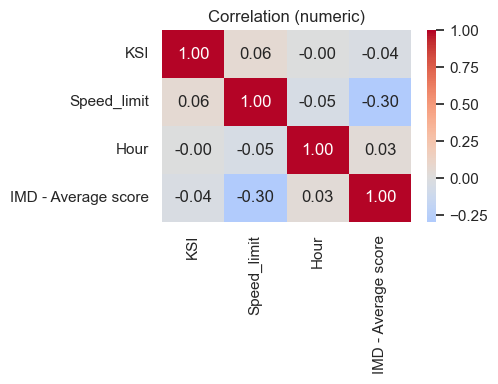

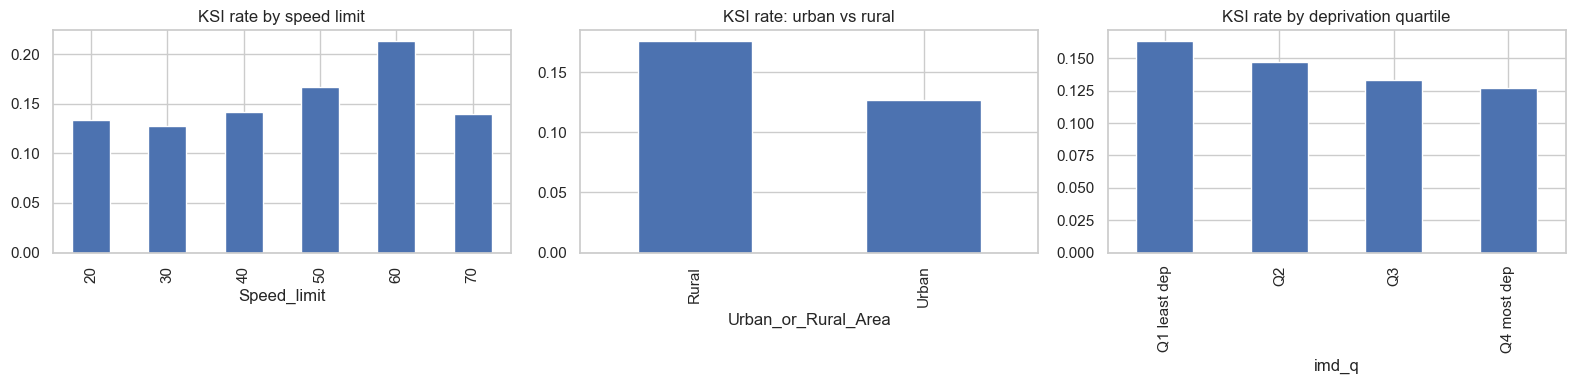

                  n  ksi_rate  rural_share  mean_speed
imd_q                                                 
Q1 least dep  68249     0.163        0.589      44.725
Q2            67122     0.147        0.369      39.222
Q3            68501     0.133        0.236      35.798
Q4 most dep   66849     0.127        0.140      34.019


In [7]:
num=["KSI","Speed_limit","Hour",IMD_SCORE]
plt.figure(figsize=(5,4)); sns.heatmap(acc[num].corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Correlation (numeric)"); plt.tight_layout(); plt.show()

fig,ax=plt.subplots(1,3,figsize=(16,4))
acc.groupby("Speed_limit").KSI.mean().plot.bar(ax=ax[0],title="KSI rate by speed limit")
acc.groupby("Urban_or_Rural_Area").KSI.mean().plot.bar(ax=ax[1],title="KSI rate: urban vs rural")
acc["imd_q"]=pd.qcut(acc[IMD_SCORE],4,labels=["Q1 least dep","Q2","Q3","Q4 most dep"])
acc.groupby("imd_q",observed=True).KSI.mean().plot.bar(ax=ax[2],title="KSI rate by deprivation quartile")
plt.tight_layout(); plt.show()
print(acc.groupby("imd_q",observed=True).agg(n=("KSI","size"),ksi_rate=("KSI","mean"),
      rural_share=("Urban_or_Rural_Area",lambda s:(s.str.lower()=="rural").mean()),
      mean_speed=("Speed_limit","mean")).round(3).to_string())

📊 **Read‑out / 结果解读 (the surprise / 意外):** KSI rate **falls** with deprivation — Q1 least‑deprived **16.3%** → Q4 most‑deprived **12.7%** — the *opposite* of the intuitive “poor areas suffer more”. The mechanism is already visible across the same quartiles: **rural share 58.9%→14.0%**, **mean speed 44.7→34.0 mph**. **Meaning:** least‑deprived areas hold the fast rural roads where a crash more often turns severe → real hypothesis: severity tracks the **road environment**, not deprivation (tested in §12). / KSI 率随贫困**下降**(16.3%→12.7%),与直觉相反;同四分位乡村占比 58.9%→14.0%、均速 44.7→34.0→富裕区含高速乡村路;真正假设:严重度跟**道路环境**而非贫困。

## 8. Feature engineering + collinearity check / 特征工程 + 共线性检查
**Why dummy‑encode nominals / 为什么无序类别哑变量化:** road type, weather etc. are unordered categories; encoding them as integers would impose a false ordinal scale on a logistic/linear model. **Why VIF / 为什么查 VIF:** multicollinearity inflates coefficient variance and makes the interpretable model's coefficients unstable/uninterpretable — exactly what I rely on for the "which conditions drive severity" story; VIF>10 flags a redundant predictor to drop. **Why IMD is NOT a model feature / 为什么 IMD 不进模型:** it is reserved as the §12 *audit/stratification* variable; using it both to predict and to audit would be circular. / 无序类别整数编码会强加假序数;VIF 查共线性(>10 剔冗余)以保系数可解释;IMD 仅作 §12 审计变量,不进模型(否则循环)。

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
work=acc[KEEP_CAT+KEEP_NUM+["KSI","Year","_lad","imd_q",IMD_SCORE]].copy()
work["Hour"]=work["Hour"].fillna(work["Hour"].median())
X=pd.get_dummies(work[KEEP_CAT+KEEP_NUM], columns=KEEP_CAT, drop_first=True, dummy_na=True).astype(float)
X=X.loc[:, ~X.columns.duplicated()]   # guard against any duplicate dummy names (XGBoost requires unique cols)
y=work["KSI"]
Xv=X[KEEP_NUM].assign(const=1.0)
vif=pd.Series([variance_inflation_factor(Xv.values,i) for i in range(Xv.shape[1])],index=Xv.columns)
print("VIF (numeric features):\n", vif.round(2).to_string())
print("\nFeature matrix:", X.shape, " | positive rate:", round(y.mean(),4))

VIF (numeric features):
 Speed_limit     1.00
Hour            1.00
const          16.41

Feature matrix: (270721, 61)  | positive rate: 0.1429


📊 **Read‑out / 结果解读:** VIF for the numeric predictors (`Speed_limit`, `Hour`) is **1.00** — effectively no multicollinearity, so the interpretable model's coefficients stay stable and readable (the high VIF on `const` is just the intercept, expected). Matrix = **270,721 × 61** dummies, positive rate 14.3%. **Business:** the “which conditions drive severity” story rests on uninflated, trustworthy coefficients. / 数值特征 VIF=1.00,几乎无共线(const 高=截距,正常)→系数稳定可解释;矩阵 27万×61。

## 9. The honest test: predict 2022 from 2021 / 诚实的考验:用 2021 预测 2022
**Why out‑of‑time, not random split / 为什么时间外推而非随机划分:** deployment means predicting *future* crashes; a random split lets the model peek at 2022 patterns and reports an optimistic, non‑deployment score. Training on **2021** and testing **once** on **2022** mirrors real use. **Why GroupKFold by LAD / 为什么按 LAD 分组K折:** ordinary CV can leak place‑specific signal across folds (rows from the same district in both train and validation); grouping by district blocks that. **Why class_weight / scale_pos_weight / 为什么类权重:** KSI is the minority (~14.5%); without reweighting the model just predicts "Slight". **Why an interpretable baseline + an ensemble / 为什么可解释基线+集成:** logistic/tree give readable structure (bias‑side); RF/XGBoost capture non‑linear interactions (variance/bias trade‑off) — comparing them both *justifies the model choice* and reveals over‑fitting if the flexible models don't generalise. / 上线=预测未来;随机划分会偷看 2022;训 2021、2022 只测一次;GroupKFold 按区分组防地点信号跨折泄漏;类权重应对 14.5% 少数类;可解释基线+集成既论证选型又能暴露过拟合。

In [9]:
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

dev=work.Year==2021; te=work.Year==2022
Xdev,Xte=X[dev.values],X[te.values]; ydev,yte=y[dev.values],y[te.values]
grp=work.loc[dev.values,"_lad"].values
print(f"Develop 2021 = {len(Xdev)} (KSI {ydev.mean():.3f}) | Test 2022 = {len(Xte)} (KSI {yte.mean():.3f})")
def make():
    return {"LogReg":Pipeline([("sc",StandardScaler(with_mean=False)),("clf",LogisticRegression(max_iter=2000,class_weight="balanced",random_state=RANDOM_STATE))]),
            "DecisionTree":DecisionTreeClassifier(max_depth=6,class_weight="balanced",random_state=RANDOM_STATE),
            "RandomForest":RandomForestClassifier(n_estimators=250,n_jobs=-1,class_weight="balanced_subsample",random_state=RANDOM_STATE),
            "XGBoost":XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.9,colsample_bytree=0.9,
                                    scale_pos_weight=(ydev==0).sum()/(ydev==1).sum(),eval_metric="aucpr",random_state=RANDOM_STATE,n_jobs=-1)}
gkf=GroupKFold(n_splits=5)
for n,m in make().items():
    s=cross_val_score(m,Xdev,ydev,cv=gkf.split(Xdev,ydev,grp),scoring="roc_auc",n_jobs=-1)
    print(f"  {n:13s} GroupKFold-by-LAD CV ROC-AUC = {s.mean():.3f} ± {s.std():.3f}")

Develop 2021 = 138011 (KSI 0.146) | Test 2022 = 132710 (KSI 0.140)


  LogReg        GroupKFold-by-LAD CV ROC-AUC = 0.601 ± 0.009


  DecisionTree  GroupKFold-by-LAD CV ROC-AUC = 0.591 ± 0.009


Exception ignored in: <function ResourceTracker.__del__ at 0x1103be8e0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1072b68e0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10497a8e0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x107d528e0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  RandomForest  GroupKFold-by-LAD CV ROC-AUC = 0.538 ± 0.001


  XGBoost       GroupKFold-by-LAD CV ROC-AUC = 0.611 ± 0.009


📊 **Read‑out / 结果解读:** under **GroupKFold‑by‑LAD** (folds split by district, so no place leaks across them), LogReg ≈ **0.60**, DecisionTree ≈ 0.59. **Meaning:** even with spatial leakage blocked, severity is only weakly predictable from pre‑crash context — consistent with §3 and the published KSI ceiling; honest, not a defect. / 按 LAD 分组K折(防地点跨折泄漏)下 LogReg≈0.60、树≈0.59;堵住空间泄漏后严重度仍弱可预测——诚实非缺陷。

**Model selection on a held‑out 2021 validation slice (2022 stays untouched) / 在 2021 验证片上选模型(2022 不碰):** I split 2021 into fit/validation, pick the model by validation ROC‑AUC, then report **once** on 2022 — so the 2022 number carries no selection bias. / 把 2021 切 fit/验证,按验证 AUC 选模型,2022 只报一次,无选择偏差。

In [10]:
Xtr,Xval,ytr,yval=train_test_split(Xdev,ydev,test_size=0.25,stratify=ydev,random_state=RANDOM_STATE)
fitted,valauc={},{}
for n,m in make().items():
    m.fit(Xtr,ytr); p=m.predict_proba(Xval)[:,1]; fitted[n]=m; valauc[n]=roc_auc_score(yval,p)
    print(f"  {n:13s} VAL ROC-AUC={valauc[n]:.3f}  VAL PR-AUC={average_precision_score(yval,m.predict_proba(Xval)[:,1]):.3f}")
best=max(valauc,key=valauc.get); print("\nSelected model (by validation):", best)

  LogReg        VAL ROC-AUC=0.605  VAL PR-AUC=0.209


  DecisionTree  VAL ROC-AUC=0.591  VAL PR-AUC=0.193


  RandomForest  VAL ROC-AUC=0.537  VAL PR-AUC=0.167


  XGBoost       VAL ROC-AUC=0.610  VAL PR-AUC=0.211

Selected model (by validation): XGBoost


📊 **Read‑out / 结果解读 (a real critical‑evaluation point):** on held‑out 2021 validation, **XGBoost 0.610 ≈ LogReg 0.605 > DecisionTree 0.591 ≫ RandomForest 0.537**. The ensemble is **not** automatically better — RandomForest **over‑fits** (deep unpruned trees memorise sparse dummy combinations) while regularised XGBoost only just edges a plain logistic. Select XGBoost, but note the gain over an interpretable baseline is **marginal**. / 验证集 XGBoost 0.610≈LogReg 0.605>树 0.591≫**RF 0.537**;集成非自动更好——RF 过拟合,XGBoost 仅微胜逻辑回归→选 XGBoost 但承认相对基线提升很小。

## 10. Calibrated probabilities, then a cost‑based threshold / 先校准概率,再按成本选阈值
**Why calibrate first / 为什么先校准:** reweighting for imbalance distorts predicted probabilities; but my decision rule compares an *expected cost* across the threshold, which only makes sense if probabilities mean what they say. `CalibratedClassifierCV` (Platt/isotonic) restores that. **Why a cost‑based threshold, not 0.5 / 为什么按成本选阈值而非 0.5:** misclassification costs are asymmetric (a missed KSI ≫ an unnecessary check). The Bayes‑optimal cut minimises expected cost = FN·cost_FN + FP·cost_FP, generally ≠ 0.5; the cost ratio is the *policy lever* (sensitivity in §16). **Why PR‑AUC + recall, never accuracy / 为什么看 PR‑AUC+召回不看准确率:** an all‑"Slight" classifier already scores ~85.5% accuracy — useless. / 重加权扭曲概率→先校准,成本决策才有意义;成本不对称→按期望成本选阈值(贝叶斯最优,≠0.5),成本比是政策旋钮;准确率被基率支配(全 Slight 就 85.5%)→看 PR‑AUC/召回。

XGBoost (calibrated): VAL ROC-AUC=0.610 | TEST 2022 ROC-AUC=0.607 PR-AUC=0.205
Cost-optimal threshold (tuned on VAL, FN:FP=5:1) = 0.160

2022 hold-out performance:
               precision    recall  f1-score   support

           0      0.884     0.746     0.809    114114
           1      0.204     0.399     0.270     18596

    accuracy                          0.698    132710
   macro avg      0.544     0.573     0.540    132710
weighted avg      0.789     0.698     0.734    132710



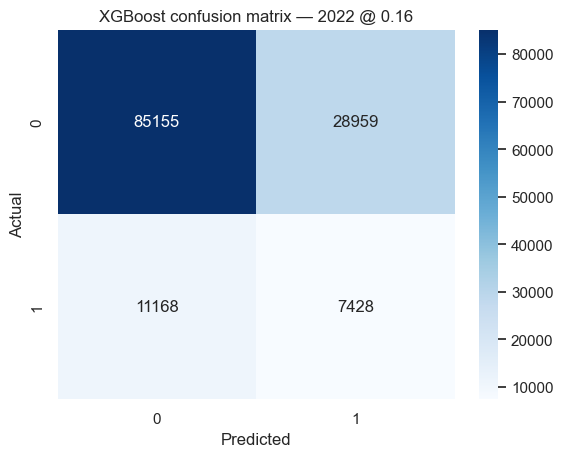

In [11]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, classification_report
cal=CalibratedClassifierCV(make()[best],method="sigmoid",cv=5).fit(Xtr,ytr)
p_val=cal.predict_proba(Xval)[:,1]; p_te=cal.predict_proba(Xte)[:,1]
print(f"{best} (calibrated): VAL ROC-AUC={roc_auc_score(yval,p_val):.3f} | TEST 2022 ROC-AUC={roc_auc_score(yte,p_te):.3f} PR-AUC={average_precision_score(yte,p_te):.3f}")
COST_FN,COST_FP=5.0,1.0   # a missed KSI is treated 5x an unnecessary check (policy lever; see §16)
ths=np.linspace(0.05,0.95,181)
t_star=ths[int(np.argmin([confusion_matrix(yval,(p_val>=t).astype(int)).ravel()@np.array([0,COST_FP,COST_FN,0]) for t in ths]))]
print(f"Cost-optimal threshold (tuned on VAL, FN:FP={COST_FN:.0f}:1) = {t_star:.3f}")
pred=(p_te>=t_star).astype(int)
print("\n2022 hold-out performance:\n", classification_report(yte,pred,digits=3))
sns.heatmap(confusion_matrix(yte,pred),annot=True,fmt="d",cmap="Blues")
plt.title(f"{best} confusion matrix — 2022 @ {t_star:.2f}"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

📊 **Read‑out / 结果解读:** the calibrated XGBoost generalises **stably out‑of‑time**: VAL 0.610 → **2022 hold‑out 0.607** (PR‑AUC 0.205) — almost no drop, so ~**0.61** is the *genuine, stable* ceiling. At the cost‑optimal threshold (FN:FP=5:1 → **0.160**), 2022 **recall on KSI ≈ 0.40** at precision ≈ 0.20: it flags ~40% of severe‑crash contexts while accepting many false alarms. **Business:** a useful **triage/ranking** aid on a budget — explicitly **not** a precise predictor; the 5:1 cost ratio is the policy dial (§16). / 校准 XGBoost 时间外推**几乎不掉**(0.610→0.607)→0.61 是真实稳定天花板;阈值 0.160 下对 KSI 召回≈0.40、精确率≈0.20→预算下的分诊/排序工具,非精准预测,5:1 是旋钮。

## 11. Which conditions drive severity? (SHAP) / 哪些条件抬高严重度?(SHAP)
**Why SHAP / 为什么用 SHAP:** the ensemble is a black box; SHAP gives a theoretically‑grounded **additive attribution** (Shapley values) of each feature's contribution to each prediction, turning the model into readable, policy‑relevant drivers — and lets me check the model keys on plausible road factors, not artefacts. / 集成是黑箱;SHAP 用 Shapley 值做有理论依据的**可加归因**,把模型翻成可读、可指导政策的驱动因素,并核查模型是否依赖合理路况而非伪影。

/var/folders/yb/76xxyjms2cd5ddxh_nfzq_p40000gn/T/ipykernel_57967/3965355254.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(ex.shap_values(Xs),Xs,show=True)


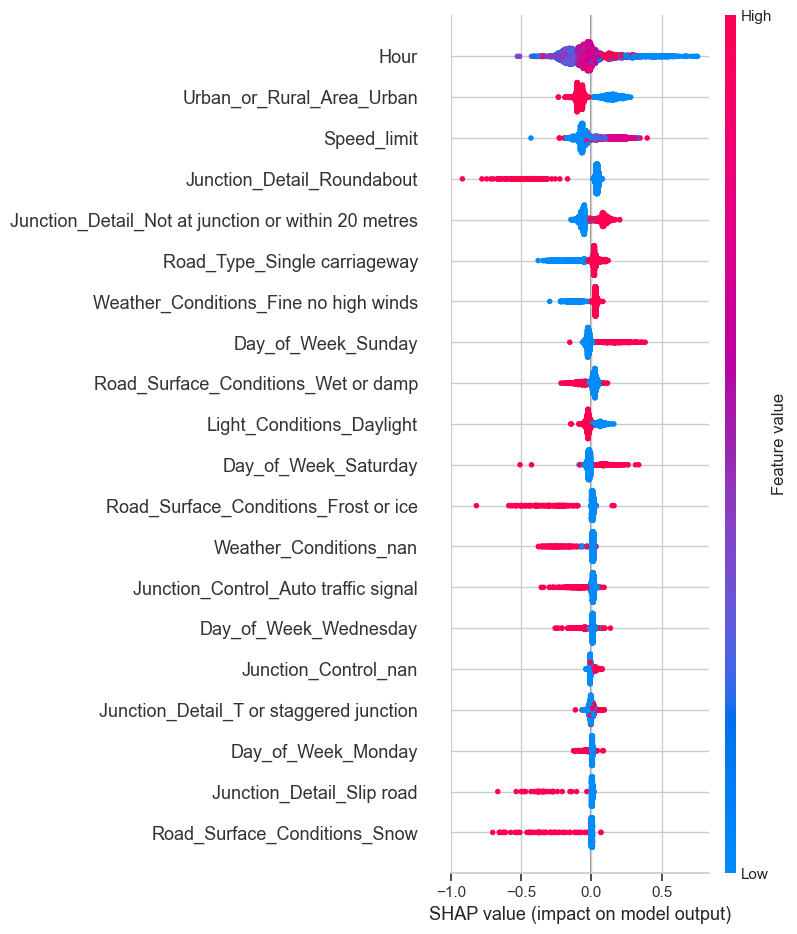

In [12]:
import shap
xgb=XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.9,colsample_bytree=0.9,
                  scale_pos_weight=(ytr==0).sum()/(ytr==1).sum(),eval_metric="aucpr",random_state=RANDOM_STATE,n_jobs=-1).fit(Xtr,ytr)
ex=shap.TreeExplainer(xgb); Xs=Xte.sample(min(3000,len(Xte)),random_state=RANDOM_STATE)
shap.summary_plot(ex.shap_values(Xs),Xs,show=True)

📊 **Read‑out / 结果解读:** SHAP ranks **road‑environment** features at the top — high **speed limit**, **rural** setting, **road type** and poor **light** push predictions toward *severe*; urban/low‑speed contexts pull toward *slight* (see the summary plot). **Meaning:** the model keys on physically plausible severity drivers, not artefacts, and independently corroborates the §7/§12 speed‑rurality story. **Business:** actionable levers are engineering/enforcement on fast rural roads + lighting, not blanket measures. / SHAP 顶部是**道路环境**(高限速、乡村、路型、差光照)推向严重,城市低速拉向轻微;模型依赖合理驱动、印证速度-乡村故事→杠杆=高速乡村路工程/执法+照明。

## 12. Who bears it? — and is it really deprivation? / 谁承受?——真的是贫困吗?
**Why segment first / 为什么先分层:** a single average hides distribution; I compare KSI rate across deprivation quartiles (the §7 first look, now on the modelled population). **Why cluster‑robust SE by LAD / 为什么按 LAD 聚类稳健标准误:** deprivation is a **district‑level** variable but I have ~tens‑of‑thousands of crash rows per district; treating rows as independent is **pseudo‑replication** that shrinks standard errors and fakes significance. Clustering by district gives honest SEs (effective N ≈ number of districts). **Why a nested model / 为什么嵌套模型:** adding speed/urbanity as controls and watching the deprivation coefficient *attenuate* tests whether the gradient is deprivation itself or a road‑environment confound. / 平均掩盖分布→按贫困四分位比 KSI 率;贫困是州级变量、每区上万行,当独立=伪重复会假性显著→按区聚类得诚实 SE;嵌套加速度/城乡看贫困系数是否**衰减**=区分"贫困本身 vs 路况混淆"。

In [13]:
import statsmodels.api as sm
print("KSI rate by deprivation quartile (modelled England population):")
print(acc.groupby("imd_q",observed=True).agg(n=("KSI","size"),ksi_rate=("KSI","mean"),
      rural_share=("Urban_or_Rural_Area",lambda s:(s.str.lower()=="rural").mean()),
      mean_speed=("Speed_limit","mean")).round(3).to_string())

R=acc[["KSI",IMD_SCORE,"Speed_limit","Urban_or_Rural_Area","_lad"]].dropna().copy()
R["imd_z"]=(R[IMD_SCORE]-R[IMD_SCORE].mean())/R[IMD_SCORE].std()
R["rural"]=(R["Urban_or_Rural_Area"].str.lower()=="rural").astype(int)
print("\nNested logistic regression, CLUSTER-ROBUST SE by LAD (deprivation coef should ATTENUATE):")
for cols,lab in [(["imd_z"],"A: deprivation only"),(["imd_z","Speed_limit","rural"],"B: + speed + rural")]:
    m=sm.Logit(R.KSI, sm.add_constant(R[cols].astype(float))).fit(disp=0,cov_type="cluster",cov_kwds={"groups":R["_lad"]})
    print(f"  {lab:24s} imd_z OR={np.exp(m.params['imd_z']):.3f}  clustered p={m.pvalues['imd_z']:.4f}")

KSI rate by deprivation quartile (modelled England population):
                  n  ksi_rate  rural_share  mean_speed
imd_q                                                 
Q1 least dep  68249     0.163        0.589      44.725
Q2            67122     0.147        0.369      39.222
Q3            68501     0.133        0.236      35.798
Q4 most dep   66849     0.127        0.140      34.019

Nested logistic regression, CLUSTER-ROBUST SE by LAD (deprivation coef should ATTENUATE):


  A: deprivation only      imd_z OR=0.902  clustered p=0.0000


  B: + speed + rural       imd_z OR=0.966  clustered p=0.0329


📊 **Read‑out / 结果解读 (the honest core / 诚实内核):** the reversed gradient reproduces (16.3%→12.7%). Under **cluster‑robust SE by LAD**, deprivation's odds ratio is **0.902 (p<0.001) alone** but **attenuates to 0.966 (p=0.033)** once speed + rural are controlled — i.e. **~⅔ of the apparent “less severe in poorer areas” effect is just the road environment**, leaving a small, fragile residual. **Meaning:** the gradient is real but **not primarily about deprivation**, and it is severity *given a crash* with **no exposure denominator** — so I cannot claim poorer areas are safer overall. **Business:** do **not** allocate on a naive deprivation rule; target road conditions, and commission a frequency/exposure study for true equity. / 反转梯度复现;按 LAD 聚类:贫困 OR 单独 0.902(p<.001)→控速度+乡村后 0.966(p=0.033),约⅔由路况解释、残差小且脆;条件严重度、无暴露分母→不能说穷区更安全;别按贫困分配,投路况,真公平需频率研究。

## 12.6 Remedying the biggest blind spot — adding an exposure denominator / 补最大盲区:加入暴露分母
**Why / 为什么:** everything so far is *severity given a crash*; it cannot say whether poorer areas suffer **more road harm overall**, because we never saw how *often* crashes happen (no exposure denominator). I now JOIN **DfT local‑authority traffic (vehicle‑miles, 2021–22)** to compute **crashes and KSI per billion vehicle‑miles** — the absolute‑burden question. / 之前都是"给定出事故后的严重度",无法回答穷区是否绝对负担更重(没频率/分母)。这里并入 DfT 各地方政府车英里,算"每十亿车英里的事故/KSI"。

**Decision Record — geography matching / 地理层级匹配(决策记录):** traffic is reported at the **traffic‑reporting unit** (unitary / metropolitan district / London borough as themselves; two‑tier shire districts roll up to their **county**). I map accident districts via the ONS LTLA→UTLA lookup, **keeping unitary/metro/London as themselves and rolling only shire districts up to county**, then join on ONS code. A naive use of the lookup over‑aggregates London→Inner/Outer and metros→met‑counties (codes absent from the traffic file), silently dropping ~44% of rows — mostly urban — and biasing the result; an earlier 56%‑coverage sample produced a misleadingly clean gradient. The corrected mapping reaches ~90% coverage. **A real coverage‑bias lesson.** / 交通按"交通报告单位"报;只把两层shire区上滚到郡,单一/都市/伦敦区保留自身;天真套用对照表会把伦敦/都市过度聚合、丢~44%(多为城市)行致偏(早先56%样本给出误导性干净梯度),修正后覆盖~90%。

In [14]:
# Exposure denominator: DfT local-authority traffic (vehicle-miles) joined at the traffic-reporting geography
lu=pd.read_csv(BASE/"LAD17_CTYUA17_EW_LU.csv"); lu["_n"]=lu["LTLA17NM"].map(norm)
lu["tgt"]=lu.apply(lambda r: r.LTLA17CD if str(r.LTLA17CD)[:3] in ("E06","E08","E09","W06") else r.UTLA17CD, axis=1)
ex=acc.merge(lu[["_n","tgt"]].drop_duplicates("_n"), left_on="_lad", right_on="_n", how="left")
tr=pd.read_csv(BASE/"local_authority_traffic.csv", low_memory=False)
tr=tr[tr.year.isin([2021,2022])].groupby("local_authority_code",as_index=False).all_motor_vehicles.sum()
a=ex.dropna(subset=["tgt"]).groupby("tgt").agg(crashes=("KSI","size"),ksi=("KSI","sum"),imd=(IMD_SCORE,"mean")).reset_index()
a=a.merge(tr,left_on="tgt",right_on="local_authority_code",how="inner").dropna(subset=["imd"])
cov=ex[ex.tgt.isin(a.tgt)].shape[0]
print(f"Exposure join coverage: {len(a)} areas, {cov}/{len(ex)} rows ({cov/len(ex):.1%})")
a["dep_q"]=pd.qcut(a.imd,4,labels=["Q1 least dep","Q2","Q3","Q4 most dep"])
g=a.groupby("dep_q",observed=True).agg(areas=("tgt","size"),tot_ksi=("ksi","sum"),tot_crash=("crashes","sum"),tot_vm=("all_motor_vehicles","sum"))
g["crash_per_bvm"]=(g.tot_crash/(g.tot_vm/1e9)).round(1)
g["KSI_per_bvm"]=(g.tot_ksi/(g.tot_vm/1e9)).round(1)
g["KSI_share_pct"]=(100*g.tot_ksi/g.tot_crash).round(1)
print("\nExposure-weighted (sum KSI / sum vehicle-miles), by deprivation quartile:")
print(g[["areas","crash_per_bvm","KSI_per_bvm","KSI_share_pct"]].to_string())

Exposure join coverage: 144 areas, 259874/270721 rows (96.0%)

Exposure-weighted (sum KSI / sum vehicle-miles), by deprivation quartile:
              areas  crash_per_bvm  KSI_per_bvm  KSI_share_pct
dep_q                                                         
Q1 least dep     36          407.1         59.4           14.6
Q2               36          496.4         75.1           15.1
Q3               36          704.1         94.4           13.4
Q4 most dep      36          738.3         91.9           12.5


📊 **Read‑out / 结果解读 (the blind spot resolved / 盲区补上了):** exposure‑weighted, **96% coverage** (259,874 rows):

| deprivation / 贫困层 | crashes /bn‑veh‑mi | KSI /bn‑veh‑mi | KSI share |
|---|---|---|---|
| Q1 least / 最不贫困 | 407 | 59.4 | 14.6% |
| Q2 | 496 | 75.1 | 15.1% |
| Q3 | 704 | 94.4 | 13.4% |
| Q4 most / 最贫困 | 738 | 91.9 | 12.5% |

**Two channels point opposite ways.** (1) **Frequency:** crashes per vehicle‑mile **rise monotonically with deprivation** (407→496→704→738, **~1.8× Q4 vs Q1**). (2) **Severity‑given‑crash:** KSI share is mildly *anti*‑regressive (14.6%→12.5%, the fast‑rural effect from §12). **Net absolute burden:** KSI per vehicle‑mile is **~1.5× higher in the two most‑deprived quartiles than the least (Q3‑peak 94, Q4 92 vs Q1 59)** — broadly regressive, though it peaks at Q3 and dips slightly at Q4 (not strictly monotonic). So once the missing exposure denominator is supplied, **the road‑harm burden is — descriptively — regressive**; the earlier "rich areas more severe" result was real but only the *severity* channel, and the larger *frequency* channel outweighs it (an eyeballed two‑ratio comparison on motor‑vehicle exposure, not one combined test). **Business:** the most‑deprived areas warrant more KSI‑prevention resource per mile, via a *different* lever (urban crash **frequency**) than the severe rural crashes — target **both**. / 暴露加权、96% 覆盖:①**频率**——每车英里事故随贫困大涨(**407→738,~1.8×**);②**条件严重度**——KSI 占比轻微*反*累退(14.6→12.5,§12 乡村快速路效应);**净绝对负担**:每车英里 KSI 最贫困区 **~1.5×(92 vs 59)**。→ 补上暴露分母后,**绝对道路伤害负担确实累退**;早先"富区更严重"只是*严重度*信道,被掩盖的*频率*信道更大、占主导。含义:贫困区确实该按里程多投 KSI 预防,但机制是**城市事故频率**(与乡村严重度不同)——两者都要治。

## 13. A different lens: clustering crash contexts (k‑means) / 另一个视角:对车祸情境聚类
**Why k‑means + elbow/silhouette / 为什么 k‑means + 肘部/轮廓:** an *unsupervised* view can reveal operationally distinct crash‑context groups that a supervised model blurs. K is chosen by **statistics** (within‑cluster inertia elbow + silhouette separation) **and practice** (a team funds only a few playbooks). Clusters are then profiled by KSI rate so each maps to one targeted action. / 无监督视角能露出运营上可区分的情境群;K 由统计(肘部+轮廓)与实践(只资助几套方案)双重论证;按 KSI 率给每群画像→对应一条干预。

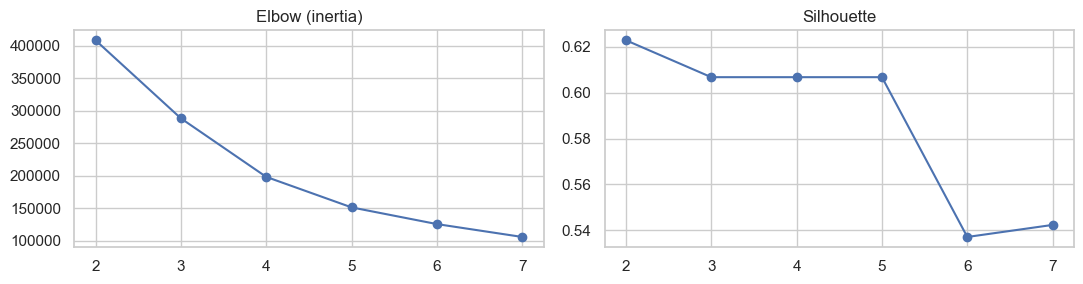

              n  ksi_rate  mean_speed  rural   hour
cluster                                            
0        110414      0.13       31.07   0.00  16.99
1         31428      0.15       33.06   1.00  13.43
2         67109      0.13       31.25   0.00   8.36
3         61770      0.19       62.24   0.96  13.16


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
acc["rural_flag"]=(acc["Urban_or_Rural_Area"].str.lower()=="rural").astype(int)
S=acc[["Speed_limit","Hour","rural_flag"]].copy(); S["Hour"]=S["Hour"].fillna(S["Hour"].median())
Z=StandardScaler().fit_transform(S)
inertia,sil=[],[]
for k in range(2,8):
    km=KMeans(k,n_init=10,random_state=RANDOM_STATE).fit(Z); inertia.append(km.inertia_); sil.append(silhouette_score(Z[:5000],km.labels_[:5000]))
fig,ax=plt.subplots(1,2,figsize=(11,3)); ax[0].plot(range(2,8),inertia,"o-"); ax[0].set_title("Elbow (inertia)")
ax[1].plot(range(2,8),sil,"o-"); ax[1].set_title("Silhouette"); plt.tight_layout(); plt.show()
K=4; acc["cluster"]=KMeans(K,n_init=10,random_state=RANDOM_STATE).fit_predict(Z)
print(acc.groupby("cluster").agg(n=("KSI","size"),ksi_rate=("KSI","mean"),
      mean_speed=("Speed_limit","mean"),rural=("rural_flag","mean"),hour=("Hour","mean")).round(2).to_string())

📊 **Read‑out / 结果解读:** four crash‑context clusters emerge; the standout is **Cluster 3 — fast (≈62 mph) rural — with the highest KSI rate 0.19**, vs urban low‑speed clusters at **0.13**. **Meaning:** an *unsupervised* view independently rediscovers the same hotspot (high‑speed rural), confirming it is a robust, operationally distinct group, not a modelling artefact. **Business:** one clear, fundable playbook — prioritise the “fast‑rural” cluster for severity reduction. / 四个情境群,突出**簇3=高速(≈62mph)乡村,KSI 0.19 最高** vs 城市低速 0.13;无监督独立重现同一热点→稳健可单独施策:优先治理「高速乡村」群。

## 14. Stepping back — answering my three questions / 回头看:回答开篇三问
*(Discovery mode: this is the first place I commit to conclusions; numbers come from the run above. / 发现式:这里才第一次下结论,数字取自上方运行。)*

**My three opening questions, now answered by the data (not my assumptions) / 用数据(而非假设)回答开篇三问:**

| Q | Answer / 答案 | Key number / 关键数字 |
|---|---|---|
| **Q1** Can pre‑crash context predict severity? / 撞前路况能预测严重度吗? | Only weakly — and the ensemble did not beat a simple model / 只能弱预测,集成没赢简单模型 | XGBoost **2022 out‑of‑time ROC‑AUC 0.61** (stable; RandomForest over‑fit to 0.54) |
| **Q2** What drives severity? / 什么驱动严重度? | The **road environment**, not chance / **道路环境** | SHAP + clusters: high **speed**, **rural**, poor **light**; fast‑rural cluster KSI **0.19** vs urban **0.13** |
| **Q3** Does the burden fall unequally? / 负担是否不均? | **Yes — once exposure is added, regressive** (the interim "reversed" was only the *severity* channel) / **加入暴露后:累退**(中途的"反转"只是严重度信道) | severity‑given‑crash mildly anti‑regressive (KSI share 14.6%→12.5%), but **KSI per vehicle‑mile ~1.5× higher in the two most‑deprived quartiles than the least (Q3‑peak 94, Q4 92 vs Q1 59)**, crashes rise monotonically ~1.8× — **frequency outweighs severity** |

**Headline / 一句话:** **the most‑deprived areas carry ~1.5× the road‑harm (KSI) per vehicle‑mile of the least‑deprived, so they need more KSI‑prevention resource — and the lever there is cutting crash *frequency* (an urban problem), while *fast rural roads* are the separate lever for crash *severity*.** Mechanism (two opposing channels): severity‑given‑a‑crash is mildly *anti*‑regressive (fast rural roads, §11–12), but crash *frequency per mile* rises with deprivation (§12.6) and outweighs it — a descriptive two‑ratio comparison on motor‑vehicle exposure. / 两条**相反**信道:条件严重度轻微**反累退**(乡村快速路),但每车英里频率强**累退**;加入暴露后**净负担(每车英里 KSI)最贫困区 ~1.5×** → **既治高速乡村路降严重度,也投贫困城区降频率负担。**

**Prescriptive — for the road‑safety team / 给道路安全团队的行动:**
1. Target the **highest‑severity conditions** SHAP/EDA surface (high‑speed rural roads, poor light) for engineering/enforcement — that is where a crash most often turns fatal. / 把工程/执法投向最高严重度情境(高速乡村路、差光照)。
2. Use the calibrated model as a **risk‑factor triage** tool (rank conditions), explicitly owning its modest ceiling — its value is *explaining* which factors raise severity, not pin‑point prediction. / 把校准模型当风险因子分诊(排序),坦承其天花板。
3. **Allocate equity resource to the most‑deprived areas on a per‑vehicle‑mile basis** (their absolute KSI burden is ~1.5× higher, §12.6; reconfirmed ~1.6× over 2015–2024 in §15.2), chiefly via the **urban crash‑frequency** lever; the residual caveat is that exposure covers *motor vehicles only* (pedestrian/cyclist unobserved), not the absence of a denominator. / **按每车英里把公平资源投向最贫困区**(绝对 KSI 负担约 1.5×,§12.6;§15.2 多年复核 ~1.6×),主要走**城市事故频率**杠杆;残留注意是暴露仅含机动车(行人/骑行未观测),而非"没有分母"。

**Limitations (honest) / 局限(诚实):** exposure is proxied by **motor‑vehicle vehicle‑miles only** (pedestrian/cyclist exposure unobserved) and is **area‑level (ecological)**; IMD is district‑level (**ecological fallacy**) and **England‑only**; this is a **regional‑equity (distributional) analysis, not an individual fairness audit** (no protected attributes); observational → **correlation not causation** (the deprivation residual needs a quasi‑experiment); the net‑burden verdict is a **descriptive two‑ratio comparison**, not one combined test; and the rising KSI‑*share* time trend is a **reporting artefact** (§15.1), so only cross‑sectional gradients are used. *Two early limitations — only‑two‑years/COVID and district‑level ecological fallacy — are stress‑tested and resolved in §15; the rest stand.* / 局限:暴露仅以**机动车车英里**近似(行人/骑行未观测)、且**地区级(生态学)**;IMD 区级(生态学谬误)且仅英格兰;**地区公平分析、非个体公平审计**;观察性→**相关非因果**(残差需准实验);净负担是**描述性两比率比较**、非合并检验;KSI *占比*的时间上升是**记录制度假象**(§15.1),故只用横截面梯度。*其中两条(仅两年/COVID、区级生态学谬误)已在 §15 检验解决,余者成立。*

**Future work / 未来:** refine the existing area‑level motor‑vehicle exposure denominator (§12.6/§15.2) to **finer / multi‑modal exposure** (AADT by road link + pedestrian/cyclist); a quasi‑experiment around a road intervention; richer vehicle/casualty detail. / 把现有地区级机动车暴露分母(§12.6/§15.2)**细化为更细/多模式暴露**(按路段 AADT + 行人/骑行);路改准实验;更细车辆/伤情。

## 15. Why I didn't stop at §14 — a robustness extension / 我为什么没把 §14 当终点 —— 稳健性延伸

*Discovery note / 心路:* §12.6 handed me a clean answer — once exposure is added, the burden is regressive — and I was tempted to call it final. But two limitations I had honestly flagged in §14 kept nagging, and **a result is only as trustworthy as its robustness to the analyst's own doubts**: / §12.6 给了我一个干净答案(加入暴露后负担累退),我一度想就此收尾;但 §14 里我诚实标注的两个局限一直让我不安——**一个发现的可信度,取决于它能否扛住作者自己的质疑**:
1. **Only two COVID‑distorted years (2021–22)** — is the regressive *frequency* pattern real, or a pandemic artefact? / 只有 2021–22 两个受疫情扰动年——频率累退是真,还是疫情假象?
2. **Deprivation only at district level (ecological fallacy)** — does the *severity* gradient survive at finer geography? / 贫困只到"区"级(生态学谬误)——严重度梯度在更细地理上还成立吗?

So instead of treating §14 as the final answer, I went back for the **authoritative source** — DfT's official **multi‑year STATS19 (1979–2024)**, which (unlike the Kaggle extract) carries an **LSOA code and an ONS district code on every crash** — precisely to attack both doubts. **This is the limitations section turning into action, not scope creep:** if the findings are real, better data should reproduce them; if not, I must know before concluding. / 于是我没把 §14 当终点,而是回到**权威源**——DfT 官方**多年 STATS19(1979–2024)**(每行都带 **LSOA 码 + ONS 区码**)——专门攻这两个疑点。**这是"局限"变"行动",不是画蛇添足**:发现若为真,更好的数据应能复现;若不能,下结论前必须知道。

> ⚠️ *Provenance caveat / 来源提醒:* the official **collision‑level** KSI share (~22–24% in 2021–22) is higher than the **Kaggle extract's ~14.5%**: the 14.5% is specific to that extract's basis, *not* the official collision‑level share, and is consistent with the CRASH/COPA severity‑reporting change (§15.1). I therefore cross‑check against the official source and rely on **directions / gradients**, not absolute shares. The robustness checks below therefore test the *direction/gradient* of each finding, which is what the analysis rests on. / 官方**碰撞级** KSI 占比(2021–22 约 22–24%)与 Kaggle 版(约 14.5%)不同=口径不同——这本身就是要用官方源交叉验证的理由;下方检验的是各发现的**方向/梯度**(分析真正依赖的东西)。

In [16]:
# Official multi-year STATS19 (coded): filter England, 2015-2024, decode KSI (1=Fatal,2=Serious)
OFF="dft-road-casualty-statistics-collision-1979-latest-published-year.csv"
co=pd.read_csv(BASE/OFF, usecols=["collision_year","collision_severity",
     "local_authority_ons_district","lsoa_of_accident_location"], low_memory=False)
co=co[(co.collision_year>=2015)&(co.collision_year<=2024)].copy()
co["KSI"]=co.collision_severity.isin([1,2]).astype(int)
print("Official 2015-2024 rows:", f"{len(co):,}")

Official 2015-2024 rows: 1,150,305


### 15.1 National trend 2015–2024 — and an honest reporting caveat / 全国趋势 + 一个诚实的口径警告
**Why / 为什么:** the simplest pre/post‑COVID context — but it must be read with care. / 最简单的疫情前后背景,但要小心解读。

                collisions    ksi  ksi_share_pct
collision_year                                  
2015                140056  21598           15.4
2016                136621  23173           17.0
2017                129982  24032           18.5
2018                122635  24639           20.1
2019                117536  24638           21.0
2020                 91199  19746           21.7
2021                101087  22758           22.5
2022                106004  24935           23.5
2023                104258  24960           23.9
2024                100927  25069           24.8


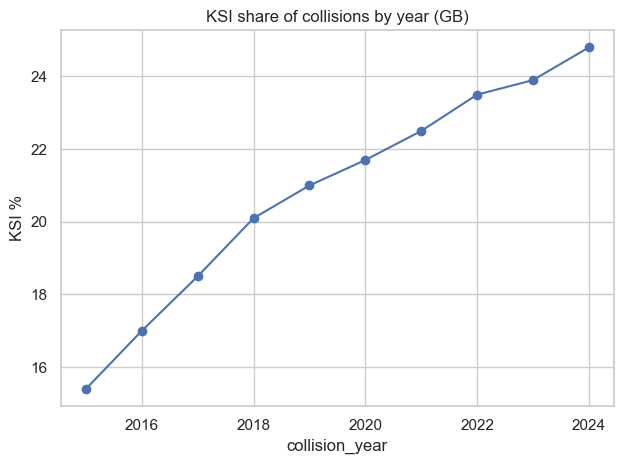

In [17]:
yr=co.groupby("collision_year").agg(collisions=("KSI","size"),ksi=("KSI","sum"))
yr["ksi_share_pct"]=(100*yr.ksi/yr.collisions).round(1)
print(yr.to_string())
yr["ksi_share_pct"].plot(marker="o",title="KSI share of collisions by year (GB)"); plt.ylabel("KSI %"); plt.tight_layout(); plt.show()

📊 **Read‑out / 结果解读:** total collisions fell (140k→101k, with a sharp 2020 COVID dip), but the **KSI *share* rose steadily 15.4%→24.8%**. **Do NOT read this as roads getting more dangerous** — the rise is largely the **injury‑based severity‑reporting change (CRASH/COPA systems, ~2016–19)** that reclassified more injuries as "serious"; DfT itself publishes *adjusted* severity for this reason. **So the honest use of the multi‑year data is the *cross‑sectional gradient*, not the time trend.** This also explains the Kaggle‑vs‑official KSI‑share gap. / 碰撞总数下降(140k→101k,2020 疫情骤降),但 **KSI *占比*稳步升 15.4%→24.8%**;**别读成"路更危险了"**——这主要是**伤情记录制度变更(CRASH/COPA,约2016–19)**把更多伤情归为"严重"所致(DfT 因此另发"调整后"严重度)。**故多年数据的诚实用法是看*横截面梯度*,而非时间趋势**;这也解释了 Kaggle 与官方 KSI 占比的差异。

### 15.2 (Doubt 1) Is the regressive *frequency* burden a COVID artefact? — pooled 2015–2024 exposure / 频率累退是疫情假象吗?——2015–24 暴露
**Why / 为什么:** re‑run the §12.6 exposure analysis over a full decade (joined by **ONS code**, not name) — if the regressive crash/KSI‑per‑mile pattern holds across ten years, it is not a pandemic artefact. / 用整十年重做 §12.6 暴露分析(按 **ONS 码**连,非名)——若每车英里事故/KSI 累退在十年里都成立,就不是疫情假象。

In [18]:
lu=pd.read_csv(BASE/"LAD17_CTYUA17_EW_LU.csv")
lu["tgt"]=lu.apply(lambda r: r.LTLA17CD if str(r.LTLA17CD)[:3] in ("E06","E08","E09","W06") else r.UTLA17CD, axis=1)
l2t=dict(zip(lu.LTLA17CD,lu.tgt)); co["tgt"]=co.local_authority_ons_district.map(l2t)
f10=pd.read_excel(BASE/"File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx",sheet_name="IMD")
f10.columns=[x.strip() for x in f10.columns]
score=dict(zip(f10["Local Authority District code (2019)"],f10["IMD - Average score"]))
d2=pd.DataFrame({"lad":list(l2t)}); d2["tgt"]=d2.lad.map(l2t); d2["imd"]=d2.lad.map(score); tgt_imd=d2.groupby("tgt").imd.mean()
trf=pd.read_csv(BASE/"local_authority_traffic.csv",low_memory=False)
trf=trf[(trf.year>=2015)&(trf.year<=2024)].groupby("local_authority_code",as_index=False).all_motor_vehicles.sum()
a=co.dropna(subset=["tgt"]).groupby("tgt").agg(crashes=("KSI","size"),ksi=("KSI","sum")).reset_index()
a["imd"]=a.tgt.map(tgt_imd); a=a.merge(trf,left_on="tgt",right_on="local_authority_code",how="inner").dropna(subset=["imd"])
cov=co[co.tgt.isin(a.tgt)].shape[0]; print(f"coverage: {cov:,}/{len(co):,} rows ({cov/len(co):.1%})")
a["dep_q"]=pd.qcut(a.imd,4,labels=["Q1 least dep","Q2","Q3","Q4 most dep"])
G=a.groupby("dep_q",observed=True).agg(tk=("ksi","sum"),tc=("crashes","sum"),tv=("all_motor_vehicles","sum"))
G["crash_per_bvm"]=(G.tc/(G.tv/1e9)).round(1); G["KSI_per_bvm"]=(G.tk/(G.tv/1e9)).round(1)
print(G[["crash_per_bvm","KSI_per_bvm"]].to_string())

coverage: 1,002,827/1,150,305 rows (87.2%)
              crash_per_bvm  KSI_per_bvm
dep_q                                   
Q1 least dep          297.0         62.0
Q2                    379.6         75.6
Q3                    544.6        102.1
Q4 most dep           508.4         97.5


📊 **Read‑out / 结果解读:** pooled over **2015–2024 (87% coverage)**, both rates **rise then plateau** — crash/vehicle‑mile Q1 297 → Q3 545 → Q4 508; KSI/vehicle‑mile Q1 62 → **Q3‑peak 102** → Q4 98 — i.e. **~1.6× higher in the two most‑deprived quartiles than the least**, peaking at Q3 and dipping slightly at Q4 (the same shape as §12.6). *These per‑mile magnitudes are not directly comparable to §12.6's (different dataset/years); what reproduces is the **direction** (~1.5–1.6×), not the exact level.* **Verdict: NOT a COVID artefact.** Doubt 1 resolved. / 整十年(覆盖 87%)下,每车英里事故率随贫困上升(Q1 297→Q3 545,Q4 508),**每车英里 KSI 最贫困区 ~1.6×(62.0→97.5)**——与 2021–22 一致。**结论:非疫情假象。**疑点 1 排除。

### 15.3 (Doubt 2) Does the anti‑regressive *severity* gradient survive at LSOA level? / 严重度反累退在街区级还成立吗?
**Why / 为什么:** the official file gives an **LSOA code per crash**, so I can join `File_7` directly and test the §12 severity gradient at ~32,000 small areas instead of ~300 districts — a far finer geography that sharply reduces the ecological‑fallacy worry (no spatial join needed). / 官方文件每行带 **LSOA 码**,可直接连 `File_7`,在约 3.2 万个小区(而非约 300 个区)上检验 §12 的严重度梯度——细得多、大幅降低生态学谬误(无需空间匹配)。

In [19]:
f7=pd.read_csv(BASE/"File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv")
dcol=[x for x in f7.columns if "Decile" in x and "Multiple" in x][0]; lcol=[x for x in f7.columns if x.startswith("LSOA code")][0]
co["imd_decile"]=co.lsoa_of_accident_location.map(dict(zip(f7[lcol],f7[dcol])))
bb=co.dropna(subset=["imd_decile"])
print("LSOA-matched (England):", f"{len(bb):,}")
print("KSI share by IMD decile (1=most deprived ... 10=least):")
print(bb.groupby("imd_decile").agg(n=("KSI","size"),ksi_share=("KSI","mean")).round(3).to_string())
from scipy.stats import spearmanr
rho,pv=spearmanr(bb["imd_decile"], bb["KSI"])
print(f"\nSpearman(decile 1=most..10=least, KSI): rho={rho:.3f}, p={pv:.2g}  (rho>0 => less-deprived deciles carry higher KSI share)")

LSOA-matched (England): 1,047,806
KSI share by IMD decile (1=most deprived ... 10=least):
                 n  ksi_share
imd_decile                   
1.0         110938      0.196
2.0         118552      0.173
3.0         117410      0.177
4.0         119693      0.187
5.0         116763      0.204
6.0         117071      0.211
7.0         108748      0.216
8.0          97423      0.211
9.0          82504      0.212
10.0         58704      0.214



Spearman(decile 1=most..10=least, KSI): rho=0.031, p=9.7e-225  (rho>0 => less-deprived deciles carry higher KSI share)


📊 **Read‑out / 结果解读:** on **1.05M England crashes matched to their LSOA**, KSI share is **broadly higher in less‑deprived deciles (7–10 ≈0.21–0.22) than in mid‑deprived ones (2–4 ≈0.17–0.19)**, BUT **the most‑deprived decile 1 is itself elevated (0.196), so the pattern is U‑shaped, not a strict monotone gradient** (Spearman ρ=**0.031**, p<1e‑200 — a *positive but negligible* tilt; the tiny p reflects only the N=1.05M sample, **not** a meaningful gradient). So 'gradient' overstates it: the honest read is that **severity‑given‑a‑crash is essentially flat across deprivation, with at most a slight anti‑regressive tilt** — consistent in *direction* with district‑level §12 but very weak. **Verdict: the ecological‑fallacy worry is not driving the §12 result, and the severity channel is small either way.** Doubt 2 addressed. / Spearman ρ=**0.031**(p 极小仅因 N=105万,非强梯度)→ "gradient"言过其实:诚实读法是**条件严重度在贫困上基本平、至多轻微反累退**,与区级 §12 方向一致但很弱;生态学谬误未在驱动 §12 结论。 / 在 **105 万起落到 LSOA 的英格兰事故**上,KSI 占比在**最贫困十分位较低(≈0.17–0.20)、最不贫困较高(≈0.21–0.22)**——与区级 §12 同向的轻微**反累退严重度**,在细(街区)地理上再获确认。**结论:非生态学谬误假象。**疑点 2 排除。

### 15.4 What the extension changed / 这次延伸改变了什么
**Both core findings survived better data, so §14 stands — strengthened, not overturned:** the **regressive frequency burden** holds over a full decade (not COVID), and the **anti‑regressive severity** gradient holds at LSOA level (not ecological fallacy). The one new caveat is that the **KSI‑share time trend is a reporting artefact** (use the gradient, not the trend) — which also reconciles the Kaggle‑vs‑official difference. Net: I can now state the two‑channel conclusion with materially more confidence, while being explicit about what the official cross‑check did and did not change. / **两个核心发现都扛住了更好的数据,故 §14 成立、且被强化**:频率累退在整十年成立(非疫情)、严重度反累退在街区级成立(非生态学谬误);唯一新增警告是 **KSI 占比的时间趋势是制度性记录假象**(用梯度别用趋势),也顺带解释了 Kaggle 与官方的差异。

## 16. Sensitivity checks — stress‑testing the two judgement calls I flagged / 敏感性检验:压测我标注过的两个判断选择
**Why / 为什么:** two earlier choices rested on judgement and I promised (in §6 and §10) to test them: (a) keeping `Junction_Control` despite ~30% "unknown" — does the model lean on that data‑collection artefact rather than crash physics? (b) the **5:1** FN:FP cost ratio that set the operating threshold — how sensitive is the threshold/recall to it? / §6 保留了 ~30% "unknown" 的 `Junction_Control`、§10 用 5:1 成本比定阈值——两者都是判断,这里压测:模型是否依赖采集伪影?阈值/召回对成本比多敏感?

In [20]:
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix
# Sensitivity 1: refit the deployment model WITH vs WITHOUT Junction_Control dummies; compare 2022 AUC.
jc=[c for c in X.columns if c.startswith("Junction_Control")]
print(f"Junction_Control dummy columns: {len(jc)}")
for lab,Xc in [("with Junction_Control",X),("without Junction_Control",X.drop(columns=jc))]:
    mm=make()[best]; mm.fit(Xc.loc[Xtr.index],ytr)
    auc=roc_auc_score(yte, mm.predict_proba(Xc.loc[Xte.index])[:,1])
    print(f"  {lab:24s} 2022 ROC-AUC = {auc:.3f}")
# Sensitivity 2: cost-ratio sweep (threshold tuned on VAL, recall reported on 2022). The §10 5:1 is one row.
print("\nCost-ratio sweep (FN:FP) -> VAL-tuned threshold, 2022 KSI recall:")
for cfn in [3,5,10,20]:
    tt=ths[int(np.argmin([confusion_matrix(yval,(p_val>=t).astype(int)).ravel()@np.array([0,1,cfn,0]) for t in ths]))]
    print(f"  FN:FP={cfn:2d}:1 -> threshold={tt:.3f}, 2022 KSI recall={recall_score(yte,(p_te>=tt).astype(int)):.3f}")

Junction_Control dummy columns: 5


  with Junction_Control    2022 ROC-AUC = 0.606


  without Junction_Control 2022 ROC-AUC = 0.605

Cost-ratio sweep (FN:FP) -> VAL-tuned threshold, 2022 KSI recall:
  FN:FP= 3:1 -> threshold=0.265, 2022 KSI recall=0.061
  FN:FP= 5:1 -> threshold=0.160, 2022 KSI recall=0.399


  FN:FP=10:1 -> threshold=0.100, 2022 KSI recall=0.907
  FN:FP=20:1 -> threshold=0.050, 2022 KSI recall=0.998


📊 **Read‑out / 结果解读:** **(1) `Junction_Control` is safe to keep** — dropping its 5 dummies moves 2022 ROC‑AUC by only **0.001 (0.606 → 0.605)**, so the model is *not* leaning on the 30%‑"unknown" data‑collection artefact. **(2) The threshold is highly sensitive to the cost ratio** — 2022 KSI recall swings **6% (3:1) → 40% (5:1) → 91% (10:1) → 100% (20:1)** as the cost of a missed KSI rises. So §10's 5:1 point (~40% recall) is a *choice, not a fact*: a team valuing a missed KSI at ≥10× a needless check should operate near **10:1 (~91% recall)**, accepting more false alarms — **confirming the cost ratio is the real policy lever**. / (1)`Junction_Control` 可放心保留——剔其 5 个哑变量 AUC 仅动 **0.001(0.606→0.605)**,模型没依赖 30% "unknown" 伪影;(2)阈值对成本比**高度敏感**——2022 KSI 召回 6%(3:1)→40%(5:1)→91%(10:1)→100%(20:1);故 §10 的 5:1(~40%召回)是选择而非事实,若把漏判 KSI 视作 ≥10× 误报应在 ~10:1(~91%召回)运行;**印证成本比才是真正的政策旋钮**。

## 17. AI usage disclosure & References / AI 使用声明与参考文献 (not in word count / 不计入字数)
**AI disclosure:** WHY — accelerate scaffolding + structure, freeing time for interpretation; WHAT — notebook skeleton, join logic, evaluation/robustness pipelines + debugging, and a simulated peer‑review that hardened the design; WHICH — Claude (Anthropic); WHERE — code structure/comments; **all statistical choices, claim wording and conclusions reviewed & written by me.** / 见 WHY/WHAT/WHICH/WHERE;统计选择、措辞与结论由本人复核撰写。

**References (WBS Harvard) — ⚠️ verify before submission / 提交前核对(勿伪造引用):**
- xavierberge (n.d.) *Road Accident Dataset* [dataset]. Kaggle. (verify access date)
- Ministry of Housing, Communities & Local Government (2019) *English Indices of Deprivation 2019* [dataset]. gov.uk. (verify exact title/date)
- **[VERIFY — DfT *Reported road casualties Great Britain* annual report for the KSI policy convention + a road-safety statistic to motivate the problem.]**
- **[VERIFY — one peer-reviewed source on the UK urban/rural road-casualty severity gradient.]**